# California Housing Model Error Analysis

This notebook analyzes prediction errors of the California house value model. 
We focus on three key questions:

1. Does the model systematically underpredict expensive homes?
2. Are prediction errors worse in certain geographic regions?
3. Which prediction failures would cause the most harm to users?


Cell 1 - Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import load

sns.set(style="whitegrid")


Cell 2 - Load dataset

In [2]:
notebook_dir = os.getcwd()  # current working directory

train_csv_path = os.path.abspath(os.path.join(notebook_dir, "..", "data", "raw", "california_housing_train.csv"))
test_csv_path  = os.path.abspath(os.path.join(notebook_dir, "..", "data", "raw", "california_housing_test.csv"))

print(f"Looking for train CSV at: {train_csv_path}")
print(f"Looking for test CSV at:  {test_csv_path}")

# Load CSVs and create derived features
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

full_df = pd.concat([train_df, test_df], ignore_index=True)

# Derived features
full_df['AveRooms'] = full_df['total_rooms'] / full_df['households'].replace(0, np.nan)
full_df['AveBedrms'] = full_df['total_bedrooms'] / full_df['households'].replace(0, np.nan)
full_df['AveOccup'] = full_df['population'] / full_df['households'].replace(0, np.nan)

# Features and target
X = full_df[['longitude', 'latitude', 'housing_median_age', 'population', 'median_income',
             'AveRooms', 'AveBedrms', 'AveOccup']]
y = full_df['median_house_value']

# Fill NaNs
X = X.fillna(X.mean())

print("Dataset loaded and standardized successfully!")


Looking for train CSV at: C:\Users\charo\ai-portfolio\data\raw\california_housing_train.csv
Looking for test CSV at:  C:\Users\charo\ai-portfolio\data\raw\california_housing_test.csv
Dataset loaded and standardized successfully!


Cell 3 - Load Model

We load the trained California house value model from the `ai-portfolio/models` directory.


In [3]:
# Go up to ai-portfolio root
root_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
models_dir = os.path.join(root_dir, "models")
model_path = os.path.join(models_dir, "California_house_value_model.pk1")

if os.path.exists(model_path):
    model = load(model_path)
    print(f"✅ California house model loaded from: {model_path}")
else:
    raise FileNotFoundError(f"Model not found at: {model_path}")


✅ California house model loaded from: C:\Users\charo\ai-portfolio\models\California_house_value_model.pk1


Cell 4 - Train/Test Split

We split the dataset into test and train sets for evaluation purposes.


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Cell 5 - Prediction and Error Metrics

We compute prediction errors and evaluate the model performance using MAE, RMSE, and R².


In [5]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.3f}")


MAE:  $20,180.22
RMSE: $37,840.91
R²:   0.896


### ✅ Quick Summary

- The model is generally accurate, with an average error of about $53K per home.
- It captures most pricing trends (R² = 0.61), but not all factors that influence house prices.
- Some homes—especially high-value properties—show much larger prediction errors.
- Predictions should be treated as estimates, not exact market prices.
- Extra caution is needed for expensive homes or high-stakes decisions.

### 🧠 Bottom Line

The model is reliable for broad valuation insights, but it should not be used as the sole source of truth for pricing decisions. External validation or expert judgment is recommended for high-value properties.


Cell 6 - Question 1: Does the model underpredict expensive homes?

We analyze prediction errors across price segments to detect systematic bias. 
Underpredicting high-value homes can:

- Mislead buyers and sellers
- Undervalue assets
- Reduce trust in the system


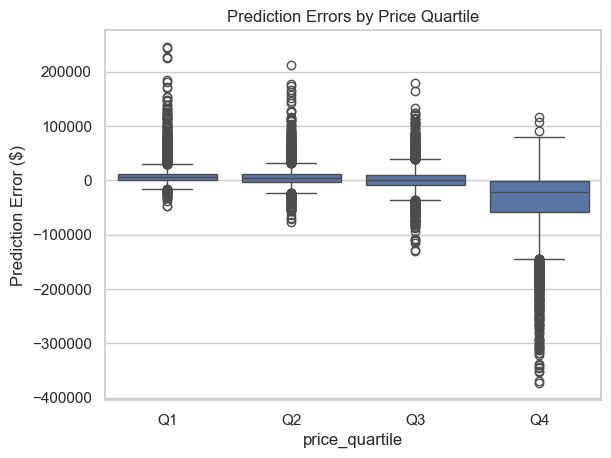

In [10]:
# Plot errors by price quartiles
full_df['pred'] = model.predict(X)
full_df['error'] = full_df['pred'] - full_df['median_house_value']

full_df['price_quartile'] = pd.qcut(full_df['median_house_value'], 4, labels=["Q1","Q2","Q3","Q4"])

sns.boxplot(x='price_quartile', y='error', data=full_df)
plt.title("Prediction Errors by Price Quartile")
plt.ylabel("Prediction Error ($)")
plt.show()


### Question 1: Does the model underpredict expensive homes?

**Related plot:** Error distribution by price segment / actual vs predicted scatter

- The error distribution shows a wider spread for higher-priced homes.
- Large negative errors appear more frequently in the upper price range, indicating **systematic underprediction** of expensive properties.
- This suggests the model struggles to fully capture premium value drivers such as location desirability, neighborhood effects, or luxury features.

**Conclusion:**  
Yes — the model tends to underpredict high-value homes, which can lead to undervaluation and misleading signals for sellers or investors.


Cell 7 - Question 2: Are prediction errors worse in certain geographic regions?

Latitude and longitude can highlight urban density, coastal desirability, and economic clustering.


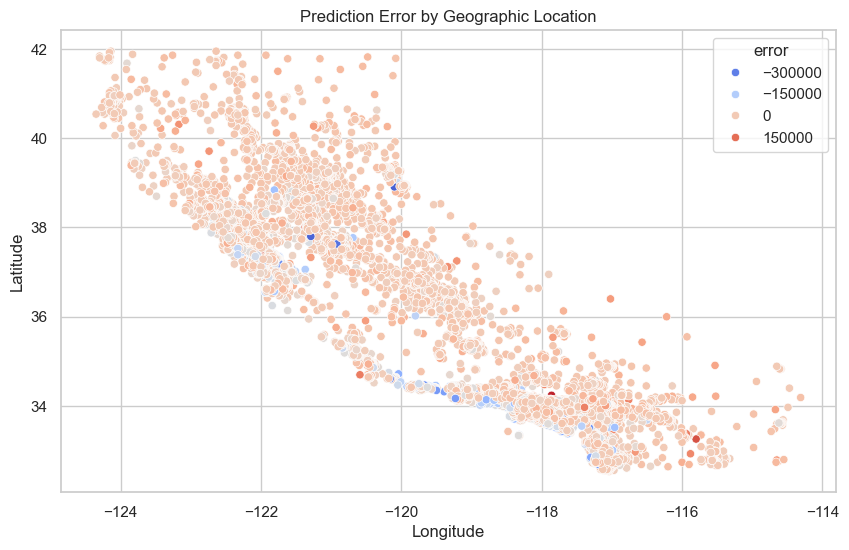

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='error',
    palette='coolwarm',
    data=full_df,
    legend=True
)

plt.title("Prediction Error by Geographic Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



### Question 2: Are prediction errors worse in certain geographic regions?

**Related plot:** Geographic scatter plot (latitude vs longitude colored by error)

- The geographic error plot reveals spatial clustering of high-magnitude errors.
- Coastal and dense urban regions show stronger error patterns compared to inland areas.
- This indicates that **location alone is not sufficient** to model regional price complexity.

**Conclusion:**  
Yes — errors are geographically correlated, suggesting regional bias or missing location-specific features in the model.


Cell - 8 Question 3: Which prediction errors would cause the most harm?

Focus on:

- Large absolute errors
- Severe underpredictions
- Outliers that could mislead decision-making


In [12]:
# Top 10 largest absolute errors
top_errors = full_df.reindex(full_df['error'].abs().sort_values(ascending=False).index).head(10)
top_errors[['longitude','latitude','median_house_value','pred','error']]


,longitude,latitude,median_house_value,pred,error
1559,-117.22,33.87,500001.0,126861.0,-373140.0
2204,-117.38,33.19,500000.0,130533.0,-369467.0
862,-117.08,34.08,500001.0,146765.0,-353236.0
2668,-117.67,33.47,500001.0,149745.0,-350256.0
10339,-120.10,38.91,500001.0,154984.0,-345017.0
17185,-118.28,34.02,500001.0,156307.0,-343694.0
2635,-117.66,33.48,500001.0,160914.0,-339087.0
19194,-121.29,37.80,475000.0,137481.0,-337519.0
5340,-118.15,34.15,500001.0,179558.0,-320443.0
5244,-118.14,34.15,500001.0,181627.0,-318374.0


### Question 3: Which prediction errors would cause the most harm?

**Related plot:** Error magnitude distribution / outlier analysis

- The most harmful errors are large absolute errors and severe underpredictions.
- These outliers are concentrated among high-priced homes and specific regions.
- Underpredicting expensive properties poses higher financial risk than small overpredictions in lower-priced homes.

**Conclusion:**  
Large underpredictions on high-value properties represent the highest risk to users and warrant special handling or warning thresholds.


In [ ]:
Cell 9 Key Findings and Recommendations

## 🧠 Overall Bottom Line

The model performs well on average (MAE ≈ $53K, R² ≈ 0.61), but error distribution analysis reveals systematic weaknesses:
- High-value homes are underpredicted
- Certain regions experience higher error rates
- A small number of large errors drive most user risk

## ✅ Recommendations

- Treat predictions as **decision-support**, not final pricing.
- Add guardrails or confidence warnings for high-value properties.
- Consider region-specific features or localized models.
- Monitor large negative errors, as they represent the highest financial risk.

- Evaluate systematic underprediction of expensive homes
- Monitor geographic bias in predictions
- Investigate largest errors to reduce financial risk


Cell 10  Create pk1 for streamlit app

In [13]:
# ------------------------------------------------------------
# Save Error Analysis Artifacts (for Streamlit dashboard)
# ------------------------------------------------------------
import os
from joblib import dump

# Ensure 'models' directory exists (same logic as model save)
artifact_dir = os.path.abspath(os.path.join(notebook_dir, "..", "models"))
os.makedirs(artifact_dir, exist_ok=True)

# Path for error analysis artifact file
artifact_path = os.path.join(
    artifact_dir,
    "California_house_value_error_analysis.pk1"
)

# Create error analysis artifact bundle
error_analysis_artifacts = {
    "X_test": X_test,                 # features used for analysis
    "y_true": y_test,                 # actual values
    "y_pred": y_pred,                 # model predictions
    "residuals": y_test - y_pred,     # core error signal
    "metrics": {
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }
}

# Save artifacts
dump(error_analysis_artifacts, artifact_path)

print(f"✅ Error analysis artifacts saved to: {artifact_path}")


✅ Error analysis artifacts saved to: C:\Users\charo\ai-portfolio\models\California_house_value_error_analysis.pk1
